In [3]:
import osmnx as ox, networkx as nx, matplotlib.cm as cm, pandas as pd, numpy as np, geopandas as gpd
import cityImage as ci

from shapely.geometry import Point, mapping
%matplotlib inline

import warnings
warnings.simplefilter(action="ignore")
pd.options.display.float_format = '{:20.2f}'.format
pd.options.mode.chained_assignment = None

In [1]:
city_name = 'Barcelona'
epsg = 2062
crs = 'EPSG:'+str(epsg)
place = 'Barcelona, Spain'
input_path = '../data/'+city_name

In [4]:
# Identify contained polygons
# Create spatial index for faster lookups

from shapely.geometry import Polygon, MultiPolygon

# Convert MultiPolygons with a single Polygon into a Polygon
def convert_multipolygon_to_polygon(geometry):
    if isinstance(geometry, MultiPolygon) and len(geometry.geoms) == 1:
        return geometry.geoms[0]  # Extract the single Polygon
    return geometry  # Return unchanged if already Polygon or a true MultiPolygon

In [160]:
obstructions = gpd.read_file(input_path+'_detailedBuildings.gpkg').to_crs(epsg)
gdf = obstructions.copy()
gdf["geometry"] = gdf["geometry"].apply(convert_multipolygon_to_polygon)

In [177]:
v = gdf[gdf.geometry.geom_type == 'MultiPolygon'].iloc[1].geometry.geoms[2] 

In [179]:
obstructions = gpd.read_file(input_path+'_test.gpkg').to_crs(epsg)

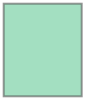

In [182]:
obstructions.iloc[0].geometry.envelope

In [162]:
def has_interior(poly):
    """Returns True if the polygon has interior rings (holes), False otherwise."""
    if poly.geom_type == "MultiPolygon":
        return false
    return len(poly.interiors) > 0

In [1]:
import geopandas as gpd
from shapely.geometry import Polygon
from shapely.ops import unary_union

while True:
    gdf['ix'] = gdf.index
    sindex = gdf.sindex  # Spatial index for faster lookups

    gdf_right = gdf.copy()
    gdf_right['geo_right'] = gdf_right.geometry
    gdf['ch'] = gdf.geometry.convex_hull
    
    # **Step 1: Spatially join polygons that might be related**
    joined = gdf.set_geometry("ch").sjoin(gdf_right, predicate="intersects", how="left").query("ix_left != ix_right")
    
    # **Step 2: Identify containment relationships in bulk**
    # contained_pairs = joined[
    #     (joined.apply(lambda row: row["geometry"].contains(row["geo_right"]), axis=1)) |
    #     (joined.apply(lambda row: is_exterior_inside_another(row["geometry"], row["geo_right"]), axis=1)) |
    #     (joined.apply(lambda row: row["geometry"].convex_hull.contains(row["geo_right"]), axis=1))
    # ]

    contained_pairs = joined[
    joined.apply(lambda row: (
        row["geometry"].contains(row["geo_right"]) or
        is_exterior_inside_another(row["geometry"], row["geo_right"]) or
        row["geometry"].convex_hull.contains(row["geo_right"])
    ), axis=1)
]

    # **Step 3: If no more contained polygons, stop processing**
    if contained_pairs.empty:
        break

    print("size", len(contained_pairs))
    
    # **Step 4: Compute new min(base) and max(height) values in bulk**
    # Compute min(base_right) and max(height_right) for each ix_left
    min_base = contained_pairs.groupby("ix_left")["base_right"].min()
    min_height = contained_pairs.groupby("ix_left")["height_right"].max()

    # **Step 5: Apply updates efficiently**
    gdf.loc[min_base.index, "base"] = gdf.loc[min_base.index, "base"].combine(min_base, min)
    gdf.loc[min_height.index, "height"] = gdf.loc[min_height.index, "height"].combine(min_height, max)

    # Group contained geometries by ix_left and perform union
    merged_geometries = (
        contained_pairs.groupby("ix_left")["ix_right"]
        .apply(lambda group: unary_union(gdf.loc[group.tolist(), "geometry"]).buffer(0.001)))

    # break
    # Merge with the existing geometry of ix_left
    gdf.loc[merged_geometries.index, "geometry"] = gdf.loc[merged_geometries.index, "geometry"].combine(
        merged_geometries, lambda g1, g2: unary_union([g1, g2]))

    # **Step 7: Drop all contained polygons in one operation**
    gdf = gdf.drop(index=contained_pairs["ix_right"].unique())

NameError: name 'gdf' is not defined

<Axes: >

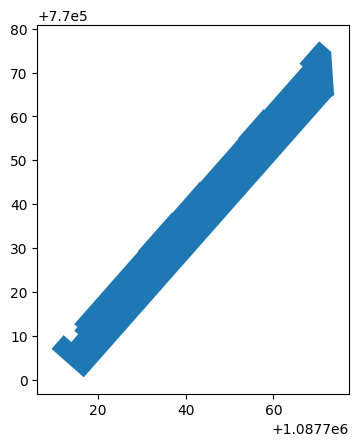

In [157]:
gdf.plot()

In [102]:
# containment_candidates.loc[0].geo_right
v = unary_union(containment_candidates.loc[0].geo_right.tolist())

In [152]:
gdf

,Zreported,base,height,ix,geometry,ch
0,38.85,38.94,56.11,0,"POLYGON ((1087773.184 770074.704, 1087770.425 ...","POLYGON ((1087716.755 770000.512, 1087709.404 ..."
1,39.20,42.30,50.10,1,"POLYGON ((1087744.413 770038.066, 1087745.103 ...","POLYGON ((1087743.877 770037.478, 1087742.036 ..."
2,39.77,40.60,53.77,2,"POLYGON ((1087758.680 770053.006, 1087756.084 ...","POLYGON ((1087757.173 770051.360, 1087754.577 ..."
3,39.88,41.20,51.11,3,"POLYGON ((1087728.546 770017.897, 1087729.687 ...","POLYGON ((1087728.546 770017.897, 1087725.495 ..."
4,51.22,46.73,51.35,4,"POLYGON ((1087758.931 770061.607, 1087758.438 ...","POLYGON ((1087752.388 770053.868, 1087751.686 ..."
5,51.18,50.10,53.67,5,"POLYGON ((1087744.518 770044.895, 1087743.792 ...","POLYGON ((1087737.809 770037.264, 1087736.982 ..."
6,51.12,45.03,54.79,6,"POLYGON ((1087730.017 770028.460, 1087729.188 ...","POLYGON ((1087723.265 770020.892, 1087722.481 ..."
7,56.14,47.52,55.73,7,"POLYGON ((1087725.061 770013.085, 1087728.149 ...","POLYGON ((1087720.245 770007.624, 1087716.156 ..."
8,55.78,53.77,54.90,8,"POLYGON ((1087757.188 770049.635, 1087753.173 ...","POLYGON ((1087749.294 770040.683, 1087745.280 ..."
9,55.78,54.40,55.16,9,"POLYGON ((1087735.830 770025.632, 1087742.467 ...","POLYGON ((1087734.690 770024.339, 1087730.701 ..."


In [146]:
obstructions.loc[0].geometry.convex_hull.contains(obstructions.loc[10].geometry)

True

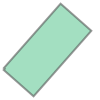

In [138]:
obstructions.loc[10].geometry

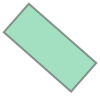

In [116]:
containment_candidates.loc[0].geo_right.iloc[1]

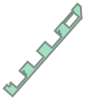

In [107]:
unary_union([v, t])

In [35]:
gdf.loc[merged_geometries.index, "geometry"] = gdf.loc[merged_geometries.index, "geometry"].combine(
        geometry, lambda g1, g2: unary_union([g1, g2]))

In [32]:
dissolved_geometry = unary_union(merged_geometries.tolist())

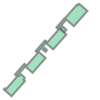

In [33]:
dissolved_geometry

In [ ]:
# Loop through all files in the folder
import os
input_folder = "C:\\Users\\gfilo\\OneDrive - The University of Liverpool\\Scripts\\cityImage\\docs\\data\\otherSources"
for file in os.listdir(input_folder):
    if file.endswith(".shp"):  # Check if it's a Shapefile
        shp_path = os.path.join(input_folder, file)
        
        # Load the Shapefile
        gdf = gpd.read_file(shp_path)
        
        # Define GeoPackage file name (same as shapefile, but with .gpkg)
        gpkg_path = os.path.join(input_folder, file.replace(".shp", ".gpkg"))
        
        # Save as GeoPackage
        gdf.to_file(gpkg_path, driver="GPKG")
        print(f"Converted: {file} → {gpkg_path}")